**Problem 1 - (a)**

Total n=300, test size=60
Empirical test R^2 (OLS): 0.87439
Empirical test R^2 (RF) : 0.74946
--- OLS ---
Empirical test R^2: 0.87439
Bootstrap mean R^2: 0.86862
Bootstrap variance : 0.000911
Bootstrap bias     : -0.005770
95% bootstrap CI   : [0.79694, 0.91637]

--- RF ---
Empirical test R^2: 0.74946
Bootstrap mean R^2: 0.73867
Bootstrap variance : 0.003123
Bootstrap bias     : -0.010789
95% bootstrap CI   : [0.61859, 0.83409]

--- Difference (OLS - RF) ---
Empirical difference: 0.124930
Bootstrap mean diff : 0.129949
Bootstrap var diff  : 0.00163804
95% bootstrap CI for difference: [0.058071, 0.220441]

95% CI for difference does NOT contain 0 -> statistically significant difference at alpha=0.05


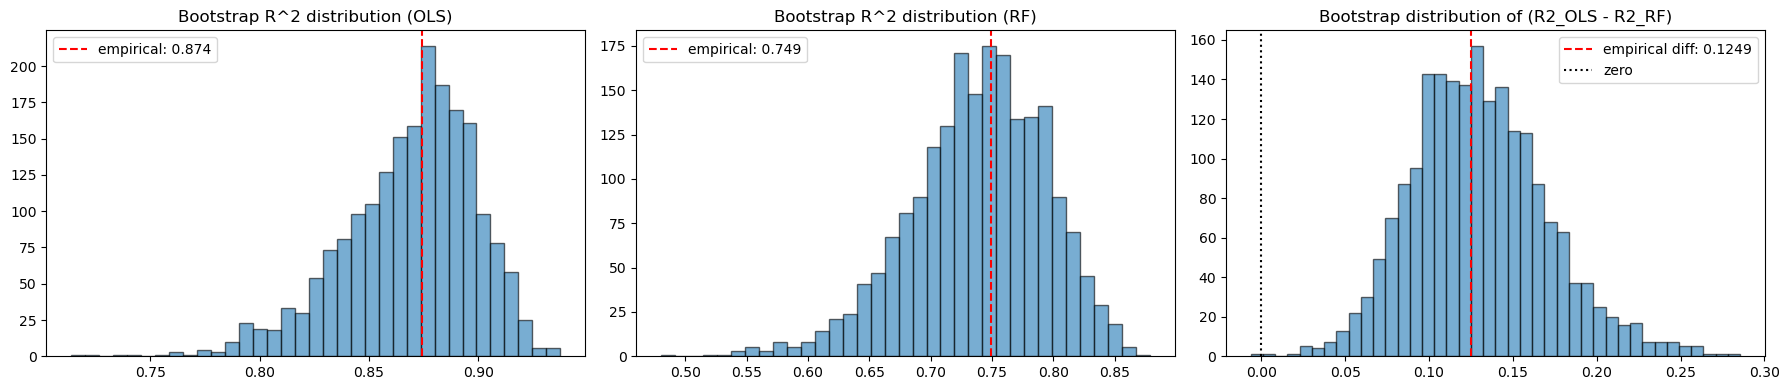

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Settings
n = 300
seed = 242
np.random.seed(seed)
test_size = 0.2
B = 2000  
alpha = 0.05

# Data generation
X = np.random.normal(loc=0.0, scale=1.0, size=n)
eps = np.random.normal(loc=0.0, scale=1.0, size=n)
Y = 1.0 + 2.5 * X + eps

# reshape for sklearn
X = X.reshape(-1, 1)
Y = Y.reshape(-1,)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=test_size, random_state=seed
)

n_test = X_test.shape[0]
print(f"Total n={n}, test size={n_test}")

# Fit models on the training set
ols = LinearRegression()
ols.fit(X_train, y_train)

rf = RandomForestRegressor(random_state=seed) 
rf.fit(X_train, y_train)

# empirical test OSR^2 using original test data
y_pred_ols = ols.predict(X_test)
y_pred_rf = rf.predict(X_test)

r2_emp_ols = r2_score(y_test, y_pred_ols)
r2_emp_rf = r2_score(y_test, y_pred_rf)

print(f"Empirical test R^2 (OLS): {r2_emp_ols:.5f}")
print(f"Empirical test R^2 (RF) : {r2_emp_rf:.5f}")

# Bootstrap on the test set
rng = np.random.RandomState(seed)  # separate RNG for bootstrap sampling
r2_boot_ols = np.empty(B)
r2_boot_rf = np.empty(B)

for i in range(B):
    # resample indices from test set WITH replacement
    idx = rng.randint(0, n_test, size=n_test)
    Xb = X_test[idx]
    yb = y_test[idx]
    # predictions from both models on the resampled test data
    yb_pred_ols = ols.predict(Xb)
    yb_pred_rf = rf.predict(Xb)
    # compute r2 on resampled pairs
    r2_boot_ols[i] = r2_score(yb, yb_pred_ols)
    r2_boot_rf[i] = r2_score(yb, yb_pred_rf)

# Bias and variance estimates from bootstrap series
def summarize_bootstrap(series, empirical_value, name=""):
    mean_b = np.mean(series)
    var_b = np.var(series, ddof=1)
    bias_b = mean_b - empirical_value
    ci_lower, ci_upper = np.percentile(series, [100*alpha/2, 100*(1-alpha/2)])
    summary = {
        "name": name,
        "empirical": empirical_value,
        "bootstrap_mean": mean_b,
        "bootstrap_variance": var_b,
        "bootstrap_bias": bias_b,
        "95%_CI": (ci_lower, ci_upper)
    }
    return summary

summary_ols = summarize_bootstrap(r2_boot_ols, r2_emp_ols, "OLS")
summary_rf  = summarize_bootstrap(r2_boot_rf, r2_emp_rf, "RF")

def print_summary(s):
    print(f"--- {s['name']} ---")
    print(f"Empirical test R^2: {s['empirical']:.5f}")
    print(f"Bootstrap mean R^2: {s['bootstrap_mean']:.5f}")
    print(f"Bootstrap variance : {s['bootstrap_variance']:.6f}")
    print(f"Bootstrap bias     : {s['bootstrap_bias']:.6f}")
    print(f"95% bootstrap CI   : [{s['95%_CI'][0]:.5f}, {s['95%_CI'][1]:.5f}]")
    print()

print_summary(summary_ols)
print_summary(summary_rf)

# Difference distribution
diff_boot = r2_boot_ols - r2_boot_rf
diff_empirical = r2_emp_ols - r2_emp_rf
diff_mean = diff_boot.mean()
diff_var = diff_boot.var(ddof=1)
diff_ci = np.percentile(diff_boot, [100*alpha/2, 100*(1-alpha/2)])

print("--- Difference (OLS - RF) ---")
print(f"Empirical difference: {diff_empirical:.6f}")
print(f"Bootstrap mean diff : {diff_mean:.6f}")
print(f"Bootstrap var diff  : {diff_var:.8f}")
print(f"95% bootstrap CI for difference: [{diff_ci[0]:.6f}, {diff_ci[1]:.6f}]")
print()

# significance check:
if diff_ci[0] > 0 or diff_ci[1] < 0:
    print("95% CI for difference does NOT contain 0 -> statistically significant difference at alpha=0.05")
else:
    print("95% CI for difference contains 0 -> no statistically significant difference at alpha=0.05")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(r2_boot_ols, bins=35, edgecolor='k', alpha=0.6)
axes[0].axvline(r2_emp_ols, color='r', linestyle='--', label=f"empirical: {r2_emp_ols:.3f}")
axes[0].set_title("Bootstrap R^2 distribution (OLS)")
axes[0].legend()

axes[1].hist(r2_boot_rf, bins=35, edgecolor='k', alpha=0.6)
axes[1].axvline(r2_emp_rf, color='r', linestyle='--', label=f"empirical: {r2_emp_rf:.3f}")
axes[1].set_title("Bootstrap R^2 distribution (RF)")
axes[1].legend()

axes[2].hist(diff_boot, bins=40, edgecolor='k', alpha=0.6)
axes[2].axvline(diff_empirical, color='r', linestyle='--', label=f"empirical diff: {diff_empirical:.4f}")
axes[2].axvline(0, color='k', linestyle=':', label="zero")
axes[2].set_title("Bootstrap distribution of (R2_OLS - R2_RF)")
axes[2].legend()

plt.tight_layout()
plt.show()

From the analysis, 95% confidence interval does not include 0, so the difference is statistically significant. The underlying data-generating process is exactly linear and thus OLS is the correctly specified model. Random Forest introduces unnecessary nonlinearity, so it is expected to perform slightly worse.

**Problem 1 - (b)**

In [2]:
np.random.seed(seed)
n_large = 5000

# Generate new dataset
X_large = np.random.normal(size=n_large)
eps_large = np.random.normal(size=n_large)
Y_large = 1 + 2.5 * X_large + eps_large

X_large = X_large.reshape(-1, 1)

# Train-test split 80/20
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_large, Y_large, test_size=test_size, random_state=seed
)

n_test_l = X_test_l.shape[0]

# Fit models
ols_l = LinearRegression().fit(X_train_l, y_train_l)
rf_l = RandomForestRegressor(random_state=seed).fit(X_train_l, y_train_l)

# Empirical test R2 on original test set
r2_emp_ols_l = r2_score(y_test_l, ols_l.predict(X_test_l))
r2_emp_rf_l  = r2_score(y_test_l, rf_l.predict(X_test_l))

print("\n\n========== n = 5000 results ==========")
print(f"Empirical test R^2 (OLS): {r2_emp_ols_l:.5f}")
print(f"Empirical test R^2 (RF) : {r2_emp_rf_l:.5f}")

# Bootstrap
rng = np.random.RandomState(seed)
r2_boot_ols_l = np.empty(B)
r2_boot_rf_l = np.empty(B)

for i in range(B):
    idx = rng.randint(0, n_test_l, size=n_test_l)
    Xb = X_test_l[idx]
    yb = y_test_l[idx]
    r2_boot_ols_l[i] = r2_score(yb, ols_l.predict(Xb))
    r2_boot_rf_l[i]  = r2_score(yb, rf_l.predict(Xb))

# Summaries
summary_ols_l = summarize_bootstrap(r2_boot_ols_l, r2_emp_ols_l, "OLS (n=5000)")
summary_rf_l  = summarize_bootstrap(r2_boot_rf_l, r2_emp_rf_l, "RF (n=5000)")

print_summary(summary_ols_l)
print_summary(summary_rf_l)

# Difference distribution
diff_boot_l = r2_boot_ols_l - r2_boot_rf_l
diff_emp_l  = r2_emp_ols_l - r2_emp_rf_l
diff_ci_l   = np.percentile(diff_boot_l, [2.5, 97.5])

print("--- Difference (OLS - RF) for n=5000 ---")
print(f"Empirical difference: {diff_emp_l:.6f}")
print(f"95% CI: [{diff_ci_l[0]:.6f}, {diff_ci_l[1]:.6f}]")

if diff_ci_l[0] > 0 or diff_ci_l[1] < 0:
    print("=> Significant difference")
else:
    print("=> NOT significant")



========== n = 5000 results ==========
Empirical test R^2 (OLS): 0.86007
Empirical test R^2 (RF) : 0.79116
--- OLS (n=5000) ---
Empirical test R^2: 0.86007
Bootstrap mean R^2: 0.85955
Bootstrap variance : 0.000064
Bootstrap bias     : -0.000518
95% bootstrap CI   : [0.84314, 0.87451]

--- RF (n=5000) ---
Empirical test R^2: 0.79116
Bootstrap mean R^2: 0.79021
Bootstrap variance : 0.000173
Bootstrap bias     : -0.000949
95% bootstrap CI   : [0.76298, 0.81425]

--- Difference (OLS - RF) for n=5000 ---
Empirical difference: 0.068910
95% CI: [0.054523, 0.085932]
=> Significant difference


The difference of the two models’ test performances is still significant. This new conclusion is more trustworthy than the n=300 result because the much larger sample size reduces sampling variability, making the bootstrap distribution narrower and the confidence interval more accurate. Therefore, the n=5000 result is the one we should rely on.

**Problem 2 - a)**

C:\Users\natal\AppData\Local\Temp\ipykernel_25632\2490068217.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month'] = pd.to_datetime(df['Month'])


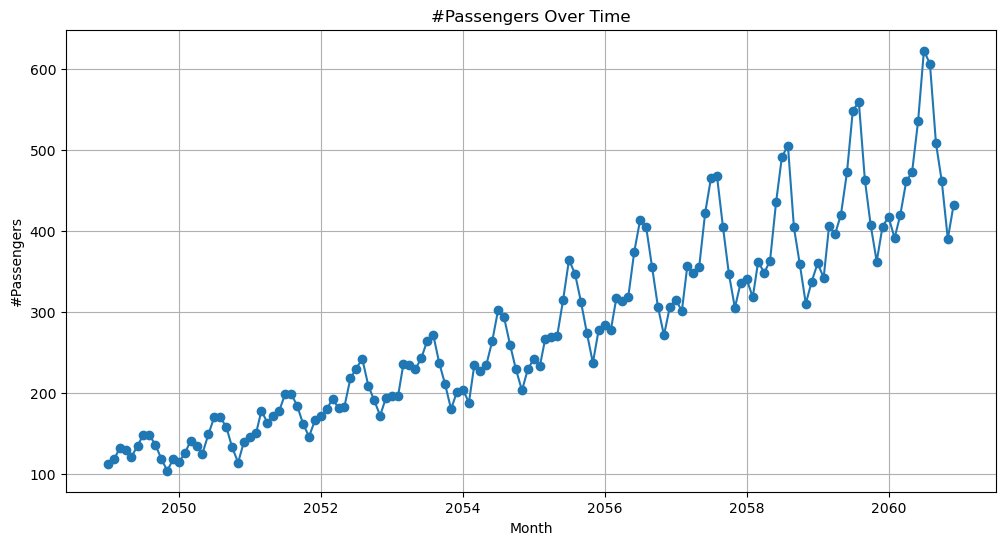

In [3]:
df = pd.read_csv("AirPassengers.csv")
df['Month'] = pd.to_datetime(df['Month'])

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['#Passengers'], marker='o')
plt.title("#Passengers Over Time")
plt.xlabel("Month")
plt.ylabel("#Passengers")
plt.grid(True)
plt.show()

There is a clear upward trend over the years, suggesting long-term growth in the number of passengers. The number of passengers steadily increases from around 100,000 in 1949 to over 600,000 by 1960.

There is also a repeating pattern within each year - that is the number of passengers peaks roughly at the same month and dips roughly at the same month each year. This indicates strong yearly seasonality, likely due to seasonal travel patterns.

With regards to stationarity, this series does not appear stationary because mean and variance change over time. The upward trend of the graph indicates increase in mean and the larger fluctuation as time goes by suggests increase in variance.

**Problem 2 - b)**

Linear Trend Model:
Intercept (β0): 97.46101928374654
Slope (β1): 2.494912841169526
Training R^2 = 0.8355617995786744
Test OSR^2 = -0.0029625785503968327


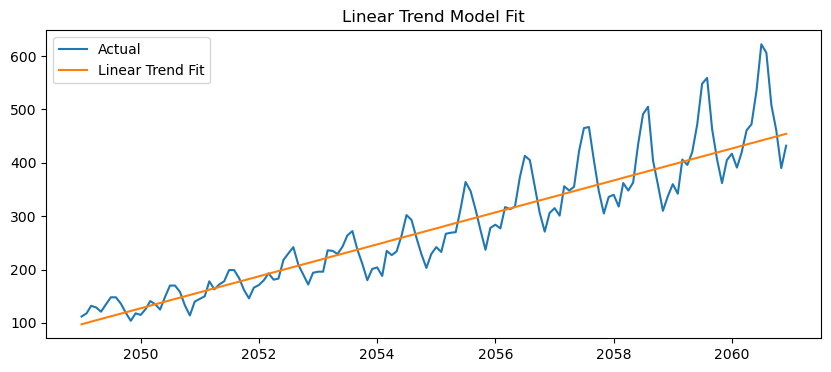


AR(1) Model:
Training R^2 = 0.9099037305067524
Test OSR^2 = 0.5208218472403917


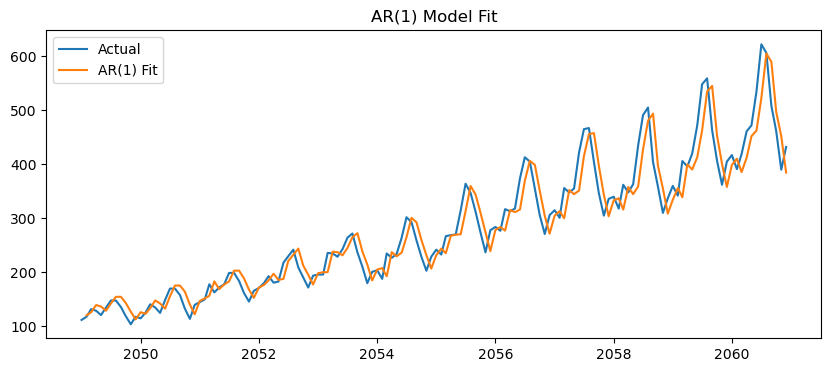

In [4]:
df['t'] = np.arange(len(df))  # time index

# Train/test split
train = df.iloc[:-24]
test = df.iloc[-24:]

X_train = train[['t']]
X_test = test[['t']]
y_train = train['#Passengers']
y_test = test['#Passengers']

# Linear Trend Model
lin = LinearRegression()
lin.fit(X_train, y_train)

y_pred_train = lin.predict(X_train)
y_pred_test = lin.predict(X_test)

print("Linear Trend Model:")
print("Intercept (β0):", lin.intercept_)
print("Slope (β1):", lin.coef_[0])
print("Training R^2 =", r2_score(y_train, y_pred_train))
print("Test OSR^2 =", r2_score(y_test, y_pred_test))

plt.figure(figsize=(10,4))
plt.plot(df['Month'], df['#Passengers'], label="Actual")
plt.plot(df['Month'], np.concatenate([y_pred_train, y_pred_test]), 
         label="Linear Trend Fit")
plt.legend()
plt.title("Linear Trend Model Fit")
plt.show()

# AR(1) Model
df['lag1'] = df['#Passengers'].shift(1)

train_ar = df.iloc[1:-24]
test_ar = df.iloc[-24:]

X_train_ar = train_ar[['lag1']]
X_test_ar = test_ar[['lag1']]
y_train_ar = train_ar['#Passengers']
y_test_ar = test_ar['#Passengers']

ar1 = LinearRegression()
ar1.fit(X_train_ar, y_train_ar)

y_pred_train_ar = ar1.predict(X_train_ar)
y_pred_test_ar = ar1.predict(X_test_ar)

print("\nAR(1) Model:")
print("Training R^2 =", r2_score(y_train_ar, y_pred_train_ar))
print("Test OSR^2 =", r2_score(y_test_ar, y_pred_test_ar))

plt.figure(figsize=(10,4))
plt.plot(df['Month'], df['#Passengers'], label="Actual")
plt.plot(df['Month'][1:], 
         np.concatenate([y_pred_train_ar, y_pred_test_ar]),
         label="AR(1) Fit")
plt.legend()
plt.title("AR(1) Model Fit")
plt.show()

Expected yearly increas in passenger numbers is the coefficient of time variable in the linear trend model, which is β1: 2.494912841169526

Because AR(1) only uses the previous observation and assumes stationarity, it underfits the upward trend and misses the repeating yearly pattern. As a result, although it fits reasonably in-sample, its test OSR² is low, showing poor out-of-sample performance.

**Problem 2 - c)**

In [5]:
import statsmodels.api as sm

# Rename column once
df.rename(columns={"#Passengers": "Passengers"}, inplace=True)

# Month dummies
df['MonthNum'] = df['Month'].dt.month
month_dummies = pd.get_dummies(df['MonthNum'], prefix='m', drop_first=True)
month_dummies = month_dummies.astype(int)

# Lags
for lag in [1,2,12,13]:
    df[f'lag{lag}'] = df['Passengers'].shift(lag)

# Combine full dataset
full = pd.concat([df, month_dummies], axis=1)

# Drop missing rows (from lags)
full = full.dropna()

# Remove non-numeric column
full = full.drop(columns=['Month'])

# Force numeric
for col in full.columns:
    full[col] = pd.to_numeric(full[col], errors='coerce')

full = full.dropna()

# Train/test
train2 = full.iloc[:-24]
test2  = full.iloc[-24:]

X_train2 = train2.drop(columns=['Passengers'])
X_test2  = test2.drop(columns=['Passengers'])
y_train2 = train2['Passengers']
y_test2  = test2['Passengers']

# OLS
X_train2_sm = sm.add_constant(X_train2)
X_test2_sm  = sm.add_constant(X_test2)

model = sm.OLS(y_train2, X_train2_sm).fit()
print(model.summary())

y_pred_train2 = model.predict(X_train2_sm)
y_pred_test2  = model.predict(X_test2_sm)

print("Training R^2:", r2_score(y_train2, y_pred_train2))
print("Test OSR^2:", r2_score(y_test2, y_pred_test2))

                            OLS Regression Results                            
Dep. Variable:             Passengers   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     576.6
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           2.66e-83
Time:                        19:52:02   Log-Likelihood:                -384.67
No. Observations:                 107   AIC:                             803.3
Df Residuals:                      90   BIC:                             848.8
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.8118      5.276      1.670      0.0

Model equation: Passengers = 8.8118 + 0.1625*t + 0.8094*lag1 − 0.0371*lag2 + 0.8091*lag12 − 0.6433*lag13 + ∑βi*m_i + ϵ

In [6]:
def backward_elimination(X, y, significance_level=0.05):
    Xc = sm.add_constant(X)
    model = sm.OLS(y, Xc).fit()

    while True:
        pvals = model.pvalues.drop('const')
        max_p = pvals.max()

        if max_p > significance_level:
            worst = pvals.idxmax()
            print(f"Removing {worst} (p = {max_p:.4f})")
            X = X.drop(columns=[worst])
            Xc = sm.add_constant(X)
            model = sm.OLS(y, Xc).fit()
        else:
            break

    return X, model

X_train_selected, model_selected = backward_elimination(X_train2, y_train2)

print("\n===== FINAL SELECTED MODEL SUMMARY =====")
print(model_selected.summary())

X_test_selected = X_test2[X_train_selected.columns]

X_train_selected_sm = sm.add_constant(X_train_selected)
X_test_selected_sm  = sm.add_constant(X_test_selected)

y_pred_train_selected = model_selected.predict(X_train_selected_sm)
y_pred_test_selected  = model_selected.predict(X_test_selected_sm)

print("Training R^2:", r2_score(y_train2, y_pred_train_selected))
print("Test OSR^2:", r2_score(y_test2, y_pred_test_selected))

Removing MonthNum (p = 0.8852)
Removing lag2 (p = 0.6502)
Removing m_5 (p = 0.7580)
Removing m_12 (p = 0.7518)
Removing m_8 (p = 0.3847)
Removing t (p = 0.5948)
Removing m_3 (p = 0.3410)
Removing m_4 (p = 0.1388)
Removing m_2 (p = 0.1087)
Removing m_10 (p = 0.1888)
Removing m_11 (p = 0.2317)
Removing m_7 (p = 0.1192)
Removing m_6 (p = 0.1838)
Removing m_9 (p = 0.0860)

===== FINAL SELECTED MODEL SUMMARY =====
                            OLS Regression Results                            
Dep. Variable:             Passengers   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     2940.
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           1.32e-99
Time:                        19:52:02   Log-Likelihood:                -394.20
No. Observations:                 107   AIC:                             796.4
Df Residuals:                     

Feature selection done by backward elimination (remove one by one)
Final model equation: Passengers = 5.0042 + 0.7955*lag1 + 1.0855*lag12 − 0.8782*lag13  

Training R²: 0.9884551567155241
Test OSR²: 0.9449635847804926


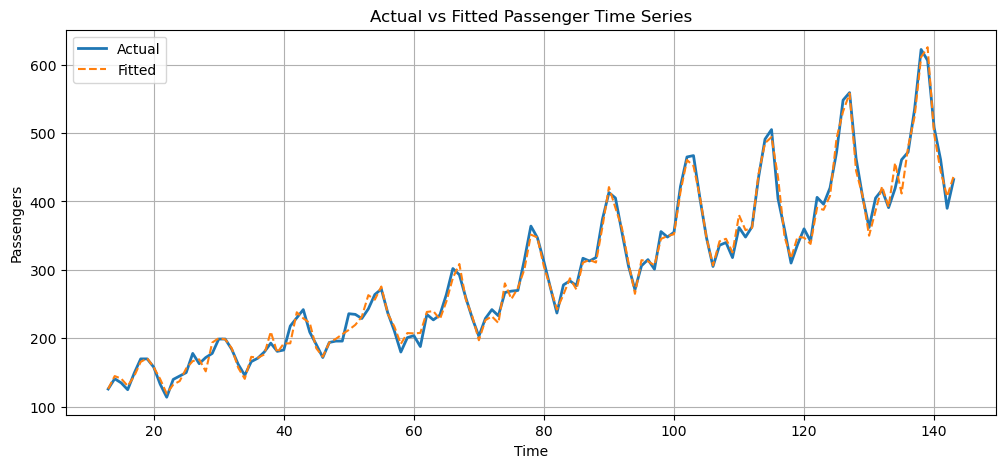

In [7]:
model_to_use = model_selected
X_train_use = sm.add_constant(X_train_selected)
X_test_use  = sm.add_constant(X_test_selected)

y_pred_train = model_to_use.predict(X_train_use)
y_pred_test  = model_to_use.predict(X_test_use)

train_R2 = r2_score(y_train2, y_pred_train)
test_OSR2 = r2_score(y_test2, y_pred_test)

print("Training R²:", train_R2)
print("Test OSR²:", test_OSR2)

# Plot full fitted vs actual (train + test)
full_pred = pd.concat([
    pd.Series(y_pred_train, index=X_train_selected.index),
    pd.Series(y_pred_test, index=X_test_selected.index)
]).sort_index()

plt.figure(figsize=(12,5))
plt.plot(full['Passengers'], label='Actual', linewidth=2)
plt.plot(full_pred, label='Fitted', linestyle='--')

plt.title('Actual vs Fitted Passenger Time Series')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

**Problem 2 - d)**

Best n_estimators = 50
CV R² = 0.2871046914831702
Random Forest:
Training R^2 = 0.9943006949241344
Test OSR^2 = 0.5626019149659482


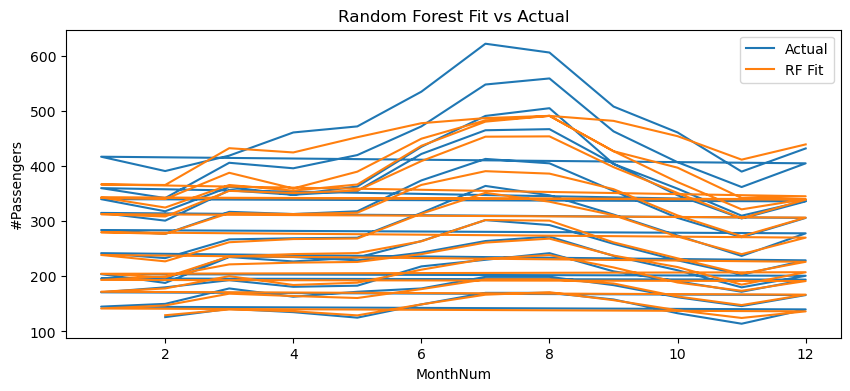

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

results = {}

# Hyperparameter tuning
for n in [10, 50, 100, 200]:
    rf = RandomForestRegressor(n_estimators=n, random_state=0)
    tscv = TimeSeriesSplit(n_splits=5)

    # Cross-validated R²
    cv_scores = cross_val_score(rf, X_train2, y_train2, cv=tscv, scoring='r2')
    results[n] = cv_scores.mean()

# Best n_estimators
best_n = max(results, key=results.get)
print("Best n_estimators =", best_n)
print("CV R² =", results[best_n])

# Fit final model
rf_final = RandomForestRegressor(n_estimators=best_n, random_state=0)
rf_final.fit(X_train2, y_train2)

y_pred_train_rf = rf_final.predict(X_train2)
y_pred_test_rf = rf_final.predict(X_test2)

print("Random Forest:")
print("Training R^2 =", r2_score(y_train2, y_pred_train_rf))
print("Test OSR^2 =", r2_score(y_test2, y_pred_test_rf))

# Build full prediction series
full_pred_rf = pd.concat([
    pd.Series(y_pred_train_rf, index=X_train2.index),
    pd.Series(y_pred_test_rf, index=X_test2.index)
]).sort_index()

month_index = pd.concat([X_train2['MonthNum'], X_test2['MonthNum']]).sort_index()

actual_series = pd.concat([y_train2, y_test2]).sort_index()

# Plot
plt.figure(figsize=(10,4))
plt.plot(month_index, actual_series, label="Actual")
plt.plot(month_index, full_pred_rf, label="RF Fit")
plt.xlabel("MonthNum")
plt.ylabel("#Passengers")
plt.title("Random Forest Fit vs Actual")
plt.legend()
plt.show()

**Problem 2 - e)**

C:\Users\natal\AppData\Local\Temp\ipykernel_25632\1173089832.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month'] = pd.to_datetime(df['Month'])
C:\Users\natal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\natal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\natal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 diff12   No. Observations:                  132
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -510.625
Date:                Fri, 21 Nov 2025   AIC                           1027.250
Time:                        19:52:07   BIC                           1035.898
Sample:                    01-01-2050   HQIC                          1030.764
                         - 12-01-2060                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.0166      3.952      7.848      0.000      23.271      38.762
ar.L1          0.7566      0.062     12.284      0.000       0.636       0.877
sigma2       133.2748     12.962     10.282      0.0

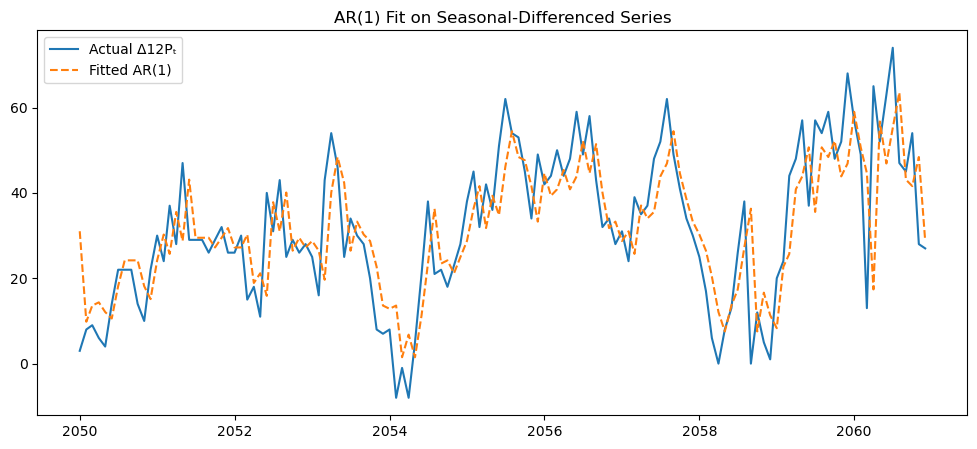

In [9]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv("AirPassengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

df['#Passengers'] = df['#Passengers'].astype('float64')

df['diff12'] = df['#Passengers'].diff(12)

diff12 = df['diff12'].dropna()

model = ARIMA(diff12, order=(1,0,0))
fit = model.fit()

print(fit.summary())

plt.figure(figsize=(12,5))
plt.plot(diff12, label='Actual Δ12Pₜ')
plt.plot(fit.fittedvalues, label='Fitted AR(1)', linestyle='--')
plt.title("AR(1) Fit on Seasonal-Differenced Series")
plt.legend()
plt.show()

Comment:
After applying seasonal differencing with lag 12, the series becomes stationary based on the Dickey-Fuller test (p < 0.05). Fitting an AR(1) model to Δ₁₂Pₜ shows that the AR(1) coefficient is significant, and the model captures the short-term autocorrelation structure reasonably well. The fitted values track the differenced series closely, although some noise remains, indicating that more complex models (ARMA or SARIMA) could capture the pattern even better.